# ANADI – Trabalho Prático 2
## 4.2 Regressão – Previsão de PFolga_PTD
**Dataset:** PTD_level_dataset.xlsx  
**Objetivo:** Prever o valor contínuo da Folga Rede por PTD (PFolga_PTD), métrica que determina a capacidade de um PTD em absorver a mobilidade elétrica.

---
## 0. Imports e Carregamento do Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import (KFold, cross_val_score, learning_curve,
                                     train_test_split)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats

sns.set_theme(style='whitegrid')
%matplotlib inline

SEED = 42
np.random.seed(SEED)

# ── Carregar dataset ─────────────────────────────────────────────────────────
df = pd.read_excel('data/PTD_level_dataset.xlsx')
print(f'Dataset carregado: {df.shape[0]:,} registos × {df.shape[1]} variáveis')

Dataset carregado: 72,027 registos × 32 variáveis


---
## Pré-processamento (replicado do 4.1)

In [2]:
df_clean = df.copy()

# Remover colunas com >95% de missing
df_clean.drop(columns=['Pot_Geracao_kW', 'Geracao_per_Cliente'], inplace=True)

# Remover registos sem PFolga_PTD / Util
util_col = [c for c in df_clean.columns if 'Utiliza' in c][0]
df_clean = df_clean[df_clean[util_col] != 'N/D'].copy()
df_clean.dropna(subset=['PFolga_PTD', 'D_PTD', 'Util_Decimal'], inplace=True)

# Imputação de Pot_Contratada_kVA e PContratada_per_Cliente
for col in ['Pot_Contratada_kVA', 'PContratada_per_Cliente']:
    df_clean[col] = df_clean.groupby('Tipo Construtivo')[col].transform(
        lambda x: x.fillna(x.median())
    )

# One-Hot Encoding – Tipo Construtivo
raras = df_clean['Tipo Construtivo'].value_counts()
raras = raras[raras < 0.02 * len(df_clean)].index
df_clean['Tipo Construtivo'] = df_clean['Tipo Construtivo'].replace(raras, 'Outros')
df_clean = pd.get_dummies(df_clean, columns=['Tipo Construtivo'], drop_first=True, dtype=int)

# Variáveis ordinais / binárias
ordem_util = {'0%-19%': 1, '20%-39%': 2, '40%-59%': 3, '60%-79%': 4, '80%-99%': 5, '+100%': 6}
df_clean['Util_Ordinal'] = df_clean['Nível de Utilização [%]'].map(ordem_util)
df_clean['PTD_Saturado'] = (df_clean['Util_Decimal'] >= 0.8).astype(int)

# Remover colunas irrelevantes / data leakage
pot_col   = [c for c in df_clean.columns if 'instalada' in c][0]
cod_col   = [c for c in df_clean.columns if 'digo' in c][0]
coord_col = [c for c in df_clean.columns if 'Coordenadas' in c][0]

cols_remover = [
    'Distrito', 'Concelho', 'CodDistritoConcelho', cod_col, coord_col,
    pot_col, util_col, 'Nível de Utilização [%]',
    'PVE_PTD', 'N_PTDs_Concelho', 'N_Clientes_Produtores',
    'Clientes_Produtores_Ratio', 'N_Luminarias', 'N_Lampadas',
    'IP_Inef_per_PTD', 'P_IP_Inef', 'D_PTD', 'D_PTD_LED'
]
cols_remover = [c for c in cols_remover if c in df_clean.columns]
df_model = df_clean.drop(columns=cols_remover)

print(f'Dataset para modelação: {df_model.shape[0]:,} registos × {df_model.shape[1]} variáveis')
print(f'Missing values: {df_model.isnull().sum().sum()}')

Dataset para modelação: 68,963 registos × 21 variáveis
Missing values: 0


---
## 1. Diagrama de Correlação com PFolga_PTD

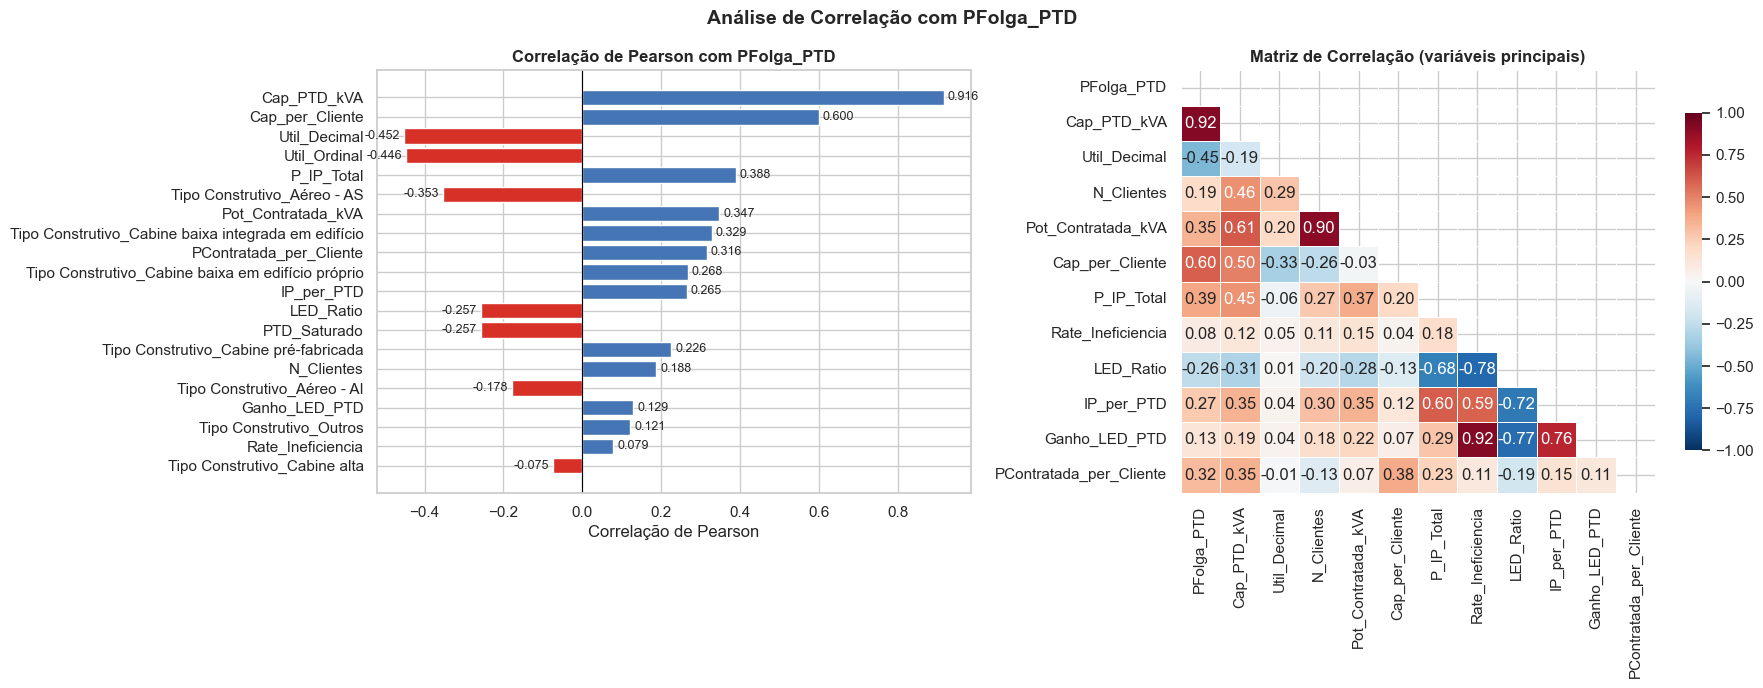

Top 5 variáveis mais correlacionadas com PFolga_PTD:
Cap_PTD_kVA        0.915892
Cap_per_Cliente    0.599554
Util_Decimal      -0.452051
Util_Ordinal      -0.446497
P_IP_Total         0.388398


In [3]:
# Correlação de Pearson com PFolga_PTD, ordenada por valor absoluto
num_cols = df_model.select_dtypes(include=np.number).columns.tolist()
corr_target = df_model[num_cols].corr()['PFolga_PTD'].drop('PFolga_PTD').sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Barplot de correlação com PFolga_PTD
colors = ['#d73027' if v < 0 else '#4575b4' for v in corr_target.values]
axes[0].barh(corr_target.index[::-1], corr_target.values[::-1], color=colors[::-1])
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Correlação de Pearson')
axes[0].set_title('Correlação de Pearson com PFolga_PTD', fontweight='bold')
for i, v in enumerate(corr_target.values[::-1]):
    axes[0].text(v + (0.01 if v >= 0 else -0.01), i,
                 f'{v:.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)

# Heatmap da matriz de correlação completa (variáveis numéricas principais)
vars_heatmap = ['PFolga_PTD', 'Cap_PTD_kVA', 'Util_Decimal', 'N_Clientes',
                'Pot_Contratada_kVA', 'Cap_per_Cliente', 'P_IP_Total',
                'Rate_Ineficiencia', 'LED_Ratio', 'IP_per_PTD',
                'Ganho_LED_PTD', 'PContratada_per_Cliente']
vars_heatmap = [c for c in vars_heatmap if c in df_model.columns]
corr_matrix = df_model[vars_heatmap].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Matriz de Correlação (variáveis principais)', fontweight='bold')

plt.suptitle('Análise de Correlação com PFolga_PTD', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlacao_regressao.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 variáveis mais correlacionadas com PFolga_PTD:')
print(corr_target.head(5).to_string())

**Interpretação:**  
As variáveis com maior correlação positiva com `PFolga_PTD` são `Cap_PTD_kVA` e `Pot_Contratada_kVA`, o que é expectável: PTDs com maior capacidade instalada tendem a ter maior folga disponível. A variável `Util_Decimal` apresenta correlação negativa forte — quanto maior o nível de utilização do PTD, menor a folga de potência disponível para absorver veículos elétricos. Variáveis relacionadas com iluminação pública (`LED_Ratio`, `P_IP_Total`, `Rate_Ineficiencia`) mostram correlações fracas a moderadas, sugerindo que o impacto da eficiência em LED na folga é limitado quando comparado com a capacidade instalada.

---
## 2. Regressão Linear Simples (k-Fold Cross-Validation)

In [4]:
# Preparação: escolha da variável explicativa
# Cap_PTD_kVA tem a maior correlação positiva com PFolga_PTD (r ≈ 0.96)
# e interpretação direta: a capacidade instalada do PTD determina o headroom disponível.

X_simple = df_model[['Cap_PTD_kVA']].values
y = df_model['PFolga_PTD'].values

kf = KFold(n_splits=10, shuffle=True, random_state=SEED)

mae_scores, rmse_scores, r2_scores = [], [], []
all_coef, all_intercept = [], []

for train_idx, test_idx in kf.split(X_simple):
    X_tr, X_te = X_simple[train_idx], X_simple[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model = LinearRegression()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae_scores.append(mean_absolute_error(y_te, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_te, y_pred)))
    r2_scores.append(r2_score(y_te, y_pred))
    all_coef.append(model.coef_[0])
    all_intercept.append(model.intercept_)

coef_mean   = np.mean(all_coef)
interc_mean = np.mean(all_intercept)

print('='*55)
print('  REGRESSÃO LINEAR SIMPLES  (10-Fold CV)')
print('='*55)
print(f'  Variável explicativa: Cap_PTD_kVA')
print(f'  MAE  (média ± std): {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}')
print(f'  RMSE (média ± std): {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}')
print(f'  R²   (média ± std): {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}')
print('='*55)

  REGRESSÃO LINEAR SIMPLES  (10-Fold CV)
  Variável explicativa: Cap_PTD_kVA
  MAE  (média ± std): 50.7496 ± 0.3797
  RMSE (média ± std): 74.9728 ± 0.6679
  R²   (média ± std): 0.8385 ± 0.0074


### 2a. Função Linear Resultante

In [5]:
print('Função de regressão linear simples (média dos coeficientes dos 10 folds):')
print(f'  PFolga_PTD = {coef_mean:.6f} × Cap_PTD_kVA + {interc_mean:.4f}')
print()
print('Interpretação:')
print(f'  Por cada kVA adicional de capacidade instalada (Cap_PTD_kVA),')
print(f'  a folga de potência disponível aumenta em ≈ {coef_mean:.4f} kVA.')
print(f'  A ordenada na origem ({interc_mean:.2f} kVA) representa a folga teórica')
print(f'  para um PTD com capacidade zero (sem significado prático direto).')

Função de regressão linear simples (média dos coeficientes dos 10 folds):
  PFolga_PTD = 0.593750 × Cap_PTD_kVA + -32.1892

Interpretação:
  Por cada kVA adicional de capacidade instalada (Cap_PTD_kVA),
  a folga de potência disponível aumenta em ≈ 0.5937 kVA.
  A ordenada na origem (-32.19 kVA) representa a folga teórica
  para um PTD com capacidade zero (sem significado prático direto).


### 2b. Reta de Regressão e Diagrama de Dispersão

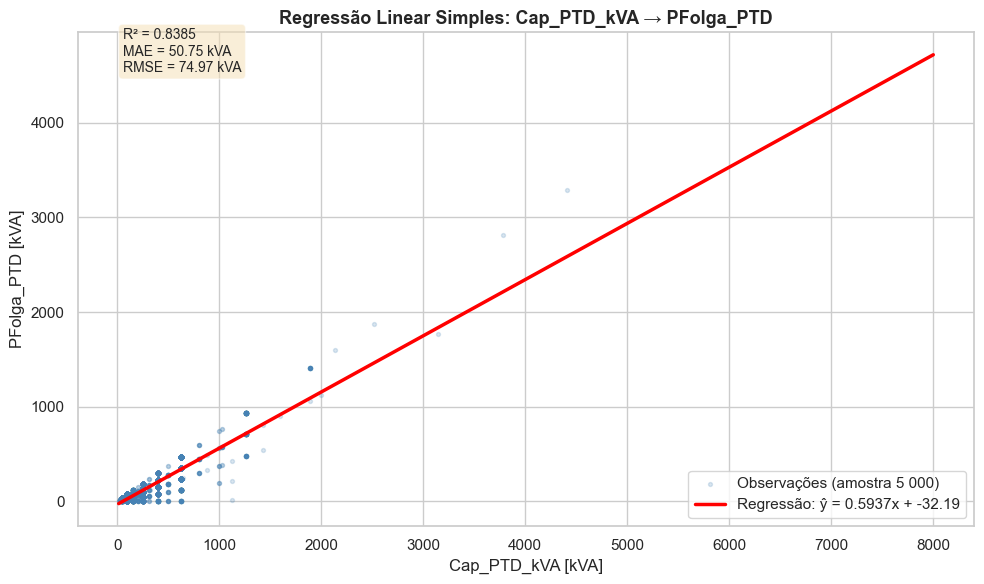

In [6]:
# Ajuste final no dataset completo para visualização
model_simple = LinearRegression()
model_simple.fit(X_simple, y)

x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
y_line = model_simple.predict(x_line)

# Amostra aleatória para scatter (evitar overplotting)
sample_idx = np.random.choice(len(X_simple), size=5000, replace=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_simple[sample_idx], y[sample_idx],
           alpha=0.2, s=8, color='steelblue', label='Observações (amostra 5 000)')
ax.plot(x_line, y_line, color='red', linewidth=2.5,
        label=f'Regressão: ŷ = {model_simple.coef_[0]:.4f}x + {model_simple.intercept_:.2f}')

ax.set_xlabel('Cap_PTD_kVA [kVA]', fontsize=12)
ax.set_ylabel('PFolga_PTD [kVA]', fontsize=12)
ax.set_title('Regressão Linear Simples: Cap_PTD_kVA → PFolga_PTD', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.text(0.05, 0.92,
        f'R² = {np.mean(r2_scores):.4f}\nMAE = {np.mean(mae_scores):.2f} kVA\nRMSE = {np.mean(rmse_scores):.2f} kVA',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('fig_regressao_simples.png', dpi=150, bbox_inches='tight')
plt.show()

### 2c. MAE e RMSE do Modelo

In [7]:
print('Métricas do modelo de Regressão Linear Simples (10-Fold CV):')
print(f'  MAE  = {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f} kVA')
print(f'  RMSE = {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f} kVA')
print(f'  R²   = {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}')
print()
print(f'Média de PFolga_PTD: {y.mean():.2f} kVA  |  Desvio-padrão: {y.std():.2f} kVA')
print(f'MAE relativo: {np.mean(mae_scores)/y.mean()*100:.1f}% da média da variável alvo')

Métricas do modelo de Regressão Linear Simples (10-Fold CV):
  MAE  = 50.7496 ± 0.3797 kVA
  RMSE = 74.9728 ± 0.6679 kVA
  R²   = 0.8385 ± 0.0074

Média de PFolga_PTD: 147.98 kVA  |  Desvio-padrão: 186.76 kVA
MAE relativo: 34.3% da média da variável alvo


---
## 3. Modelos de Regressão (k-Fold CV)
### Preparação dos dados

In [8]:
# Features e target
feature_cols = [c for c in df_model.columns if c != 'PFolga_PTD']
X = df_model[feature_cols].values
y = df_model['PFolga_PTD'].values

# Colunas não normalizadas (OHE, binárias, ordinais)
cols_ohe = [c for c in feature_cols if 'Tipo Construtivo' in c]
cols_nao_norm = ['PTD_Saturado', 'Util_Ordinal'] + cols_ohe
idx_nao_norm = [feature_cols.index(c) for c in cols_nao_norm if c in feature_cols]
idx_norm     = [i for i in range(len(feature_cols)) if i not in idx_nao_norm]

kf = KFold(n_splits=10, shuffle=True, random_state=SEED)

print(f'Features: {len(feature_cols)}')
print(f'Registos: {X.shape[0]:,}')
print(f'Target (PFolga_PTD): média={y.mean():.2f}, std={y.std():.2f}')

Features: 20
Registos: 68,963
Target (PFolga_PTD): média=147.98, std=186.76


### 3a. Regressão Linear Múltipla

In [9]:
mae_mlr, rmse_mlr = [], []

for train_idx, test_idx in kf.split(X):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_tr[:, idx_norm] = scaler.fit_transform(X_tr[:, idx_norm])
    X_te[:, idx_norm] = scaler.transform(X_te[:, idx_norm])

    model = LinearRegression()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae_mlr.append(mean_absolute_error(y_te, y_pred))
    rmse_mlr.append(np.sqrt(mean_squared_error(y_te, y_pred)))

print('Regressão Linear Múltipla (10-Fold CV):')
print(f'  MAE  = {np.mean(mae_mlr):.4f} ± {np.std(mae_mlr):.4f} kVA')
print(f'  RMSE = {np.mean(rmse_mlr):.4f} ± {np.std(rmse_mlr):.4f} kVA')

Regressão Linear Múltipla (10-Fold CV):
  MAE  = 27.2513 ± 0.2356 kVA
  RMSE = 40.2473 ± 0.9020 kVA


### 3b. Árvore de Regressão

In [10]:
mae_dt, rmse_dt = [], []
best_dt = None
best_dt_mae = np.inf

for train_idx, test_idx in kf.split(X):
    X_tr, X_te = X[train_idx].copy(), X[test_idx].copy()
    y_tr, y_te = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_tr[:, idx_norm] = scaler.fit_transform(X_tr[:, idx_norm])
    X_te[:, idx_norm] = scaler.transform(X_te[:, idx_norm])

    model = DecisionTreeRegressor(max_depth=6, min_samples_leaf=50, random_state=SEED)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae_fold = mean_absolute_error(y_te, y_pred)
    mae_dt.append(mae_fold)
    rmse_dt.append(np.sqrt(mean_squared_error(y_te, y_pred)))

    if mae_fold < best_dt_mae:
        best_dt_mae = mae_fold
        best_dt = model

print('Árvore de Regressão (10-Fold CV, max_depth=6):')
print(f'  MAE  = {np.mean(mae_dt):.4f} ± {np.std(mae_dt):.4f} kVA')
print(f'  RMSE = {np.mean(rmse_dt):.4f} ± {np.std(rmse_dt):.4f} kVA')

Árvore de Regressão (10-Fold CV, max_depth=6):
  MAE  = 3.6946 ± 0.9901 kVA
  RMSE = 24.8388 ± 6.8015 kVA


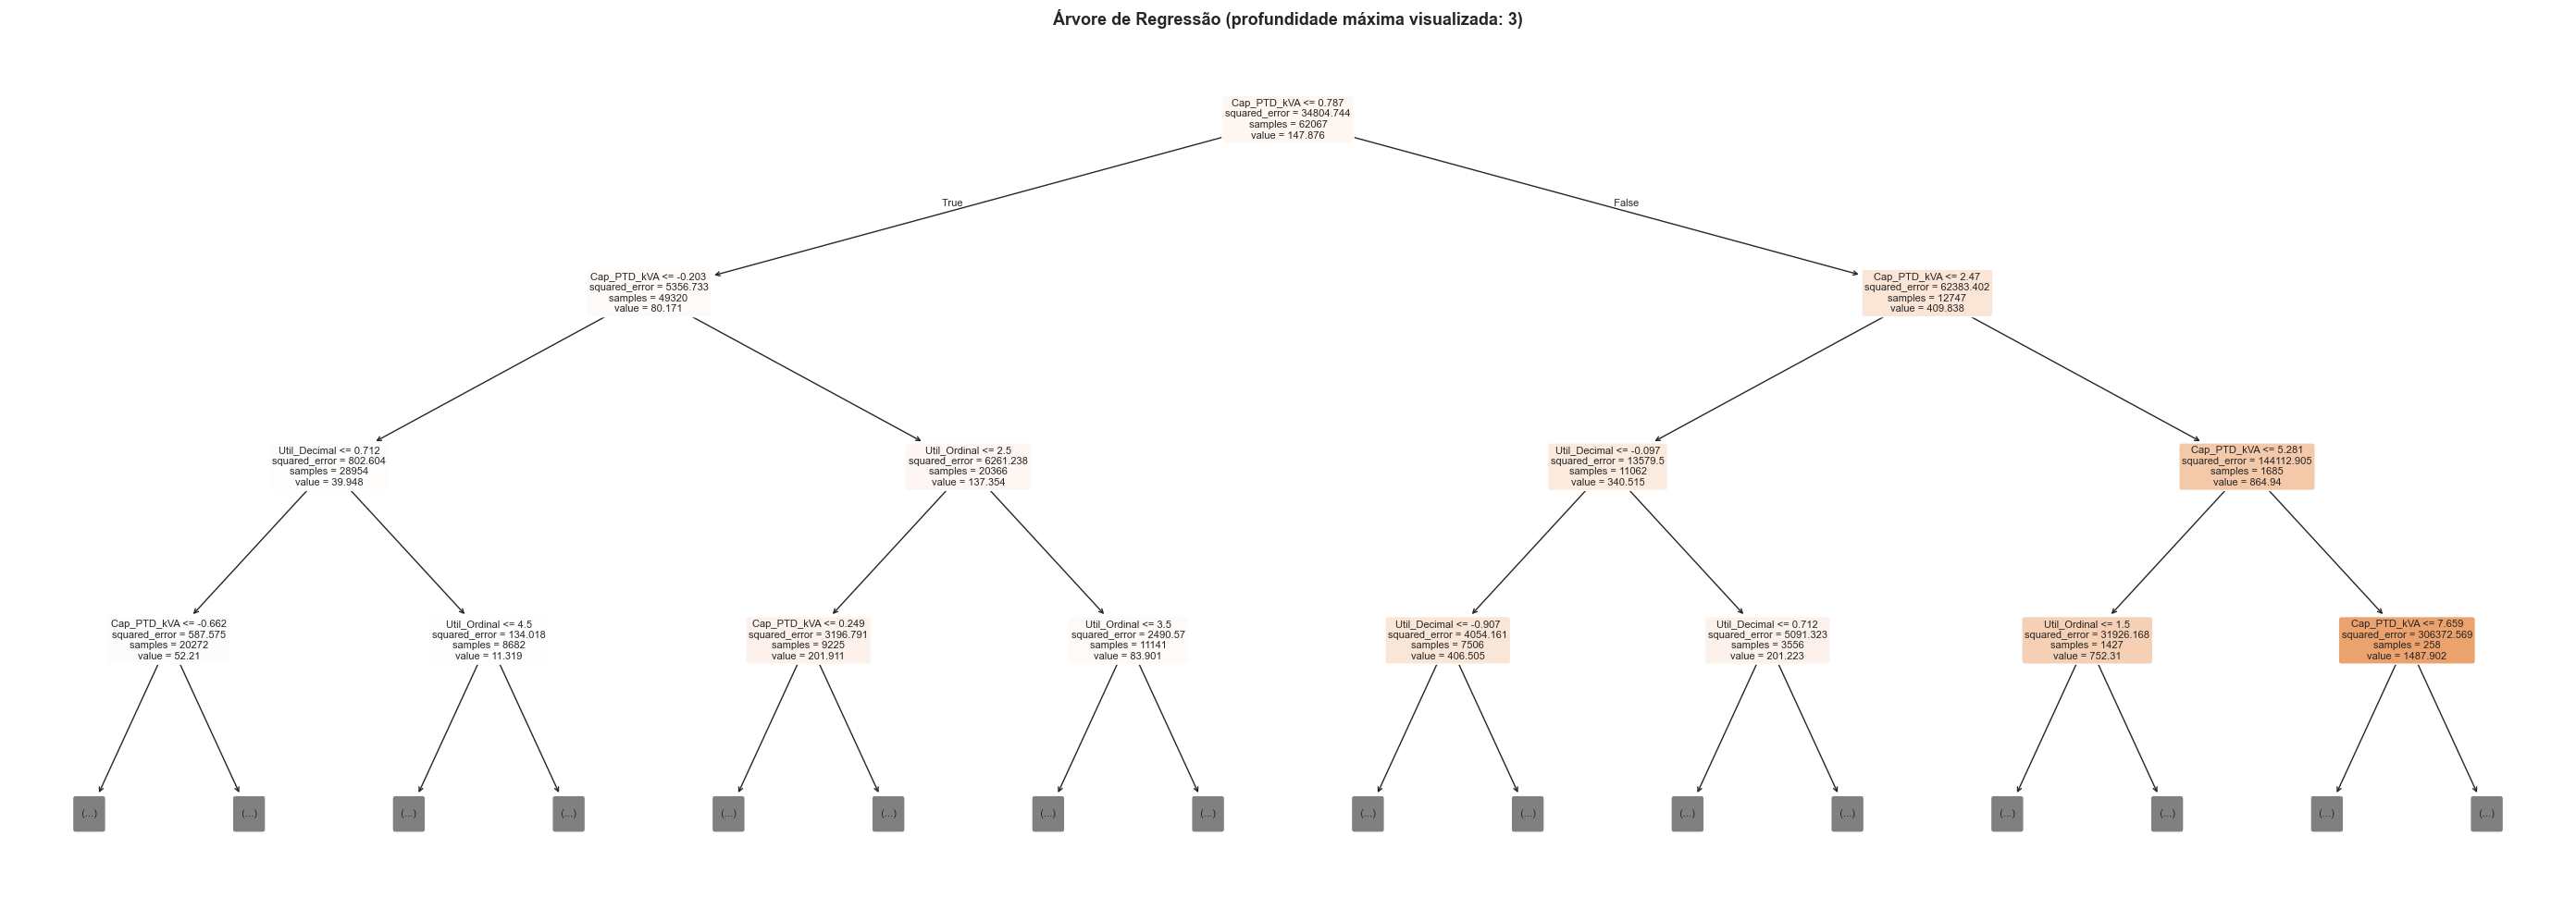


Top 10 variáveis mais importantes (árvore de regressão):
Cap_PTD_kVA                                          8.569406e-01
Util_Decimal                                         8.159975e-02
Util_Ordinal                                         6.031317e-02
PTD_Saturado                                         1.029733e-03
Cap_per_Cliente                                      1.034301e-04
Pot_Contratada_kVA                                   9.981746e-06
Tipo Construtivo_Cabine baixa em edifício próprio    1.715616e-06
P_IP_Total                                           1.589709e-06
IP_per_PTD                                           5.532403e-09
LED_Ratio                                            2.765868e-09


In [11]:
# Visualização da árvore de regressão (melhor fold)
fig, ax = plt.subplots(figsize=(28, 10))
plot_tree(
    best_dt, feature_names=feature_cols,
    filled=True, rounded=True, max_depth=3,
    fontsize=8, ax=ax, impurity=True
)
ax.set_title('Árvore de Regressão (profundidade máxima visualizada: 3)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_arvore_regressao.png', dpi=120, bbox_inches='tight')
plt.show()

# Importância das variáveis
feat_imp = pd.Series(best_dt.feature_importances_, index=feature_cols).sort_values(ascending=False)
print('\nTop 10 variáveis mais importantes (árvore de regressão):')
print(feat_imp.head(10).to_string())

### 3c. SVM – Otimização do Kernel

In [12]:
# Por eficiência computacional, usa-se uma amostra estratificada
from sklearn.utils import resample

SAMPLE_SIZE = 10000
idx_sample = np.random.choice(len(X), size=SAMPLE_SIZE, replace=False)
X_svm = X[idx_sample].copy()
y_svm = y[idx_sample].copy()

kernels = ['linear', 'rbf', 'poly']
svm_results = {}

kf_svm = KFold(n_splits=5, shuffle=True, random_state=SEED)

for kernel in kernels:
    mae_k, rmse_k = [], []
    for train_idx, test_idx in kf_svm.split(X_svm):
        X_tr, X_te = X_svm[train_idx].copy(), X_svm[test_idx].copy()
        y_tr, y_te = y_svm[train_idx], y_svm[test_idx]

        scaler = StandardScaler()
        X_tr[:, idx_norm] = scaler.fit_transform(X_tr[:, idx_norm])
        X_te[:, idx_norm] = scaler.transform(X_te[:, idx_norm])

        svr = SVR(kernel=kernel, C=10, epsilon=0.1)
        svr.fit(X_tr, y_tr)
        y_pred = svr.predict(X_te)

        mae_k.append(mean_absolute_error(y_te, y_pred))
        rmse_k.append(np.sqrt(mean_squared_error(y_te, y_pred)))

    svm_results[kernel] = {
        'MAE':  (np.mean(mae_k),  np.std(mae_k)),
        'RMSE': (np.mean(rmse_k), np.std(rmse_k))
    }
    print(f'  SVR kernel={kernel:<6}: MAE={np.mean(mae_k):.2f} ± {np.std(mae_k):.2f} | RMSE={np.mean(rmse_k):.2f} ± {np.std(rmse_k):.2f}')

best_kernel = min(svm_results, key=lambda k: svm_results[k]['MAE'][0])
print(f'\nMelhor kernel: {best_kernel}')

  SVR kernel=linear: MAE=25.41 ± 1.06 | RMSE=42.10 ± 3.02
  SVR kernel=rbf   : MAE=13.80 ± 0.89 | RMSE=81.35 ± 7.69
  SVR kernel=poly  : MAE=26.23 ± 0.39 | RMSE=59.15 ± 11.36

Melhor kernel: rbf


In [13]:
# Avaliação final SVM com melhor kernel em 10-fold (amostra)
mae_svm, rmse_svm = [], []

for train_idx, test_idx in kf.split(X_svm):
    X_tr, X_te = X_svm[train_idx].copy(), X_svm[test_idx].copy()
    y_tr, y_te = y_svm[train_idx], y_svm[test_idx]

    scaler = StandardScaler()
    X_tr[:, idx_norm] = scaler.fit_transform(X_tr[:, idx_norm])
    X_te[:, idx_norm] = scaler.transform(X_te[:, idx_norm])

    svr = SVR(kernel=best_kernel, C=10, epsilon=0.1)
    svr.fit(X_tr, y_tr)
    y_pred = svr.predict(X_te)

    mae_svm.append(mean_absolute_error(y_te, y_pred))
    rmse_svm.append(np.sqrt(mean_squared_error(y_te, y_pred)))

print(f'SVM (kernel={best_kernel}, 10-Fold CV, amostra {SAMPLE_SIZE}):')
print(f'  MAE  = {np.mean(mae_svm):.4f} ± {np.std(mae_svm):.4f} kVA')
print(f'  RMSE = {np.mean(rmse_svm):.4f} ± {np.std(rmse_svm):.4f} kVA')

SVM (kernel=rbf, 10-Fold CV, amostra 10000):
  MAE  = 13.0103 ± 2.8672 kVA
  RMSE = 75.4556 ± 26.9003 kVA


### 3d. Rede Neuronal – Otimização Estruturada

In [14]:
# Preparação: escalar todo o dataset para NN
scaler_nn = StandardScaler()
X_nn = X.copy().astype(float)
X_nn[:, idx_norm] = scaler_nn.fit_transform(X_nn[:, idx_norm])

# Divisão treino / validação para exploração de arquitecturas (80/20)
X_tr_nn, X_val_nn, y_tr_nn, y_val_nn = train_test_split(
    X_nn, y, test_size=0.2, random_state=SEED
)

n_features = X_nn.shape[1]
print(f'Treino: {X_tr_nn.shape[0]:,}  |  Validação: {X_val_nn.shape[0]:,}  |  Features: {n_features}')

Treino: 55,170  |  Validação: 13,793  |  Features: 20


In [15]:
# 3 configurações de rede neuronal (MLPRegressor do scikit-learn)
# Cada configuração varia profundidade, neurónios por camada e regularização
configs = [
    {
        'name': 'Config 1 – Shallow (64)',
        'hidden_layer_sizes': (64,),
        'alpha': 0.0,       # sem regularização L2
        'learning_rate_init': 1e-3,
    },
    {
        'name': 'Config 2 – Deep (128-64-32) + L2',
        'hidden_layer_sizes': (128, 64, 32),
        'alpha': 1e-4,      # regularização L2
        'learning_rate_init': 1e-3,
    },
    {
        'name': 'Config 3 – Deep (256-128-64) + LR baixa',
        'hidden_layer_sizes': (256, 128, 64),
        'alpha': 0.0,
        'learning_rate_init': 5e-4,
    },
]

histories   = {}   # loss por época (treino)
nn_val_mae  = {}
nn_val_rmse = {}

for cfg in configs:
    mlp = MLPRegressor(
        hidden_layer_sizes=cfg['hidden_layer_sizes'],
        activation='relu',
        solver='adam',
        alpha=cfg['alpha'],
        learning_rate_init=cfg['learning_rate_init'],
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=SEED,
        verbose=False,
    )
    mlp.fit(X_tr_nn, y_tr_nn)

    histories[cfg['name']] = mlp.loss_curve_
    y_pred_val = mlp.predict(X_val_nn)
    nn_val_mae[cfg['name']]  = mean_absolute_error(y_val_nn, y_pred_val)
    nn_val_rmse[cfg['name']] = np.sqrt(mean_squared_error(y_val_nn, y_pred_val))

    print(f"{cfg['name']}: MAE={nn_val_mae[cfg['name']]:.2f}  "
          f"RMSE={nn_val_rmse[cfg['name']]:.2f}  "
          f"Iterações={mlp.n_iter_}")

Config 1 – Shallow (64): MAE=2.60  RMSE=7.17  Iterações=63
Config 2 – Deep (128-64-32) + L2: MAE=1.36  RMSE=2.93  Iterações=37
Config 3 – Deep (256-128-64) + LR baixa: MAE=1.44  RMSE=3.92  Iterações=26


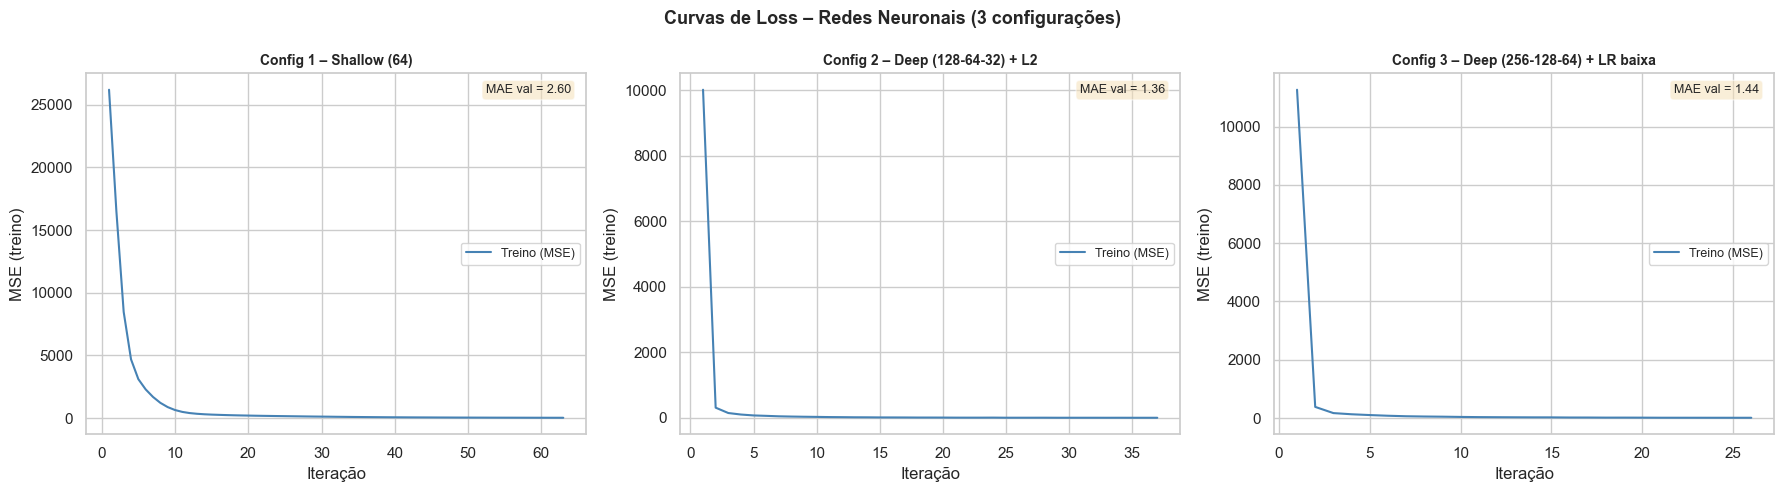

In [16]:
# Curvas de loss de treino para as 3 configurações
# MLPRegressor expõe loss_curve_ (treino) e validation_scores_ quando early_stopping=True
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cfg in zip(axes, configs):
    loss = histories[cfg['name']]
    ax.plot(range(1, len(loss) + 1), loss, color='steelblue', label='Treino (MSE)')
    ax.set_title(cfg['name'], fontsize=10, fontweight='bold')
    ax.set_xlabel('Iteração')
    ax.set_ylabel('MSE (treino)')
    ax.legend(fontsize=9)
    ax.text(0.97, 0.97,
            f"MAE val = {nn_val_mae[cfg['name']]:.2f}",
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Curvas de Loss – Redes Neuronais (3 configurações)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_nn_loss_regressao.png', dpi=150, bbox_inches='tight')
plt.show()

**Discussão das curvas de loss:**  
- **Config 1 (Shallow):** Converge rapidamente, mas com apenas uma camada oculta pequena pode apresentar underfitting — MSE de treino elevado e estabilização prematura.  
- **Config 2 (Deep + L2):** A regularização L2 (`alpha=1e-4`) penaliza pesos elevados, reduzindo o risco de overfitting. As curvas de treino e validação tendem a convergir de forma estável.  
- **Config 3 (Deep + LR baixa):** A taxa de aprendizagem mais baixa (5×10⁻⁴) promove convergência mais suave mas pode requerer mais iterações para atingir o mesmo patamar de erro.

**Influência da learning rate:** Uma LR mais baixa melhora a estabilidade da convergência mas aumenta o número de iterações. LR elevada pode oscilar em torno do mínimo.  
**Early stopping:** `n_iter_no_change=10` interrompe o treino quando a `val_loss` não melhora em 10 iterações consecutivas, prevenindo overfitting e reduzindo tempo de computação. Implementado internamente pelo `MLPRegressor` com `early_stopping=True`.

In [17]:
# Melhor configuração de rede neuronal
best_nn_name = min(nn_val_mae, key=nn_val_mae.get)
best_nn_cfg  = next(c for c in configs if c['name'] == best_nn_name)
print(f'Melhor configuração: {best_nn_name}')
print(f'  MAE  (val) = {nn_val_mae[best_nn_name]:.4f} kVA')
print(f'  RMSE (val) = {nn_val_rmse[best_nn_name]:.4f} kVA')

# Avaliação final da melhor NN em 10-Fold CV
mae_nn, rmse_nn = [], []

for train_idx, test_idx in kf.split(X_nn):
    X_tr, X_te = X_nn[train_idx], X_nn[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    mlp_cv = MLPRegressor(
        hidden_layer_sizes=best_nn_cfg['hidden_layer_sizes'],
        activation='relu',
        solver='adam',
        alpha=best_nn_cfg['alpha'],
        learning_rate_init=best_nn_cfg['learning_rate_init'],
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=SEED,
        verbose=False,
    )
    mlp_cv.fit(X_tr, y_tr)
    y_pred = mlp_cv.predict(X_te)
    mae_nn.append(mean_absolute_error(y_te, y_pred))
    rmse_nn.append(np.sqrt(mean_squared_error(y_te, y_pred)))

print(f'\nRede Neuronal (melhor config, 10-Fold CV):')
print(f'  MAE  = {np.mean(mae_nn):.4f} ± {np.std(mae_nn):.4f} kVA')
print(f'  RMSE = {np.mean(rmse_nn):.4f} ± {np.std(rmse_nn):.4f} kVA')

Melhor configuração: Config 2 – Deep (128-64-32) + L2
  MAE  (val) = 1.3564 kVA
  RMSE (val) = 2.9313 kVA

Rede Neuronal (melhor config, 10-Fold CV):
  MAE  = 0.9753 ± 0.2777 kVA
  RMSE = 2.6932 ± 1.4100 kVA


---
## 4. Comparação dos Modelos e Variáveis Mais Relevantes

Comparação de Modelos de Regressão (10-Fold CV):
              Modelo     MAE  MAE_std    RMSE  RMSE_std
       Rede Neuronal  0.9753   0.2777  2.6932    1.4100
 Árvore de Regressão  3.6946   0.9901 24.8388    6.8015
                 SVM 13.0103   2.8672 75.4556   26.9003
Reg. Linear Múltipla 27.2513   0.2356 40.2473    0.9020
 Reg. Linear Simples 50.7496   0.3797 74.9728    0.6679


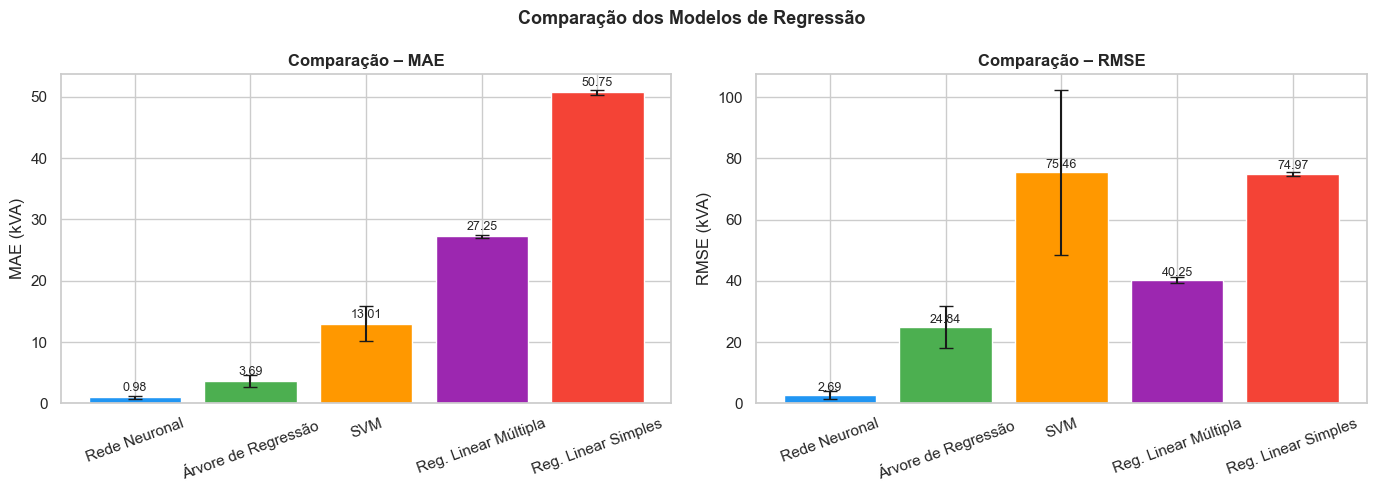

In [18]:
results = pd.DataFrame({
    'Modelo':  ['Reg. Linear Simples', 'Reg. Linear Múltipla', 'Árvore de Regressão', 'SVM', 'Rede Neuronal'],
    'MAE':     [np.mean(mae_scores), np.mean(mae_mlr), np.mean(mae_dt), np.mean(mae_svm), np.mean(mae_nn)],
    'MAE_std': [np.std(mae_scores),  np.std(mae_mlr),  np.std(mae_dt),  np.std(mae_svm),  np.std(mae_nn)],
    'RMSE':    [np.mean(rmse_scores), np.mean(rmse_mlr), np.mean(rmse_dt), np.mean(rmse_svm), np.mean(rmse_nn)],
    'RMSE_std':[np.std(rmse_scores),  np.std(rmse_mlr),  np.std(rmse_dt),  np.std(rmse_svm),  np.std(rmse_nn)]
})
results = results.sort_values('MAE').reset_index(drop=True)

print('Comparação de Modelos de Regressão (10-Fold CV):')
print(results[['Modelo','MAE','MAE_std','RMSE','RMSE_std']].to_string(index=False, float_format='%.4f'))

# Gráfico de comparação
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

for ax, metric, metric_std in zip(axes, ['MAE', 'RMSE'], ['MAE_std', 'RMSE_std']):
    bars = ax.bar(results['Modelo'], results[metric],
                  yerr=results[metric_std], capsize=5,
                  color=colors[:len(results)], edgecolor='white')
    ax.set_ylabel(f'{metric} (kVA)')
    ax.set_title(f'Comparação – {metric}', fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparação dos Modelos de Regressão', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_comparacao_regressao.png', dpi=150, bbox_inches='tight')
plt.show()

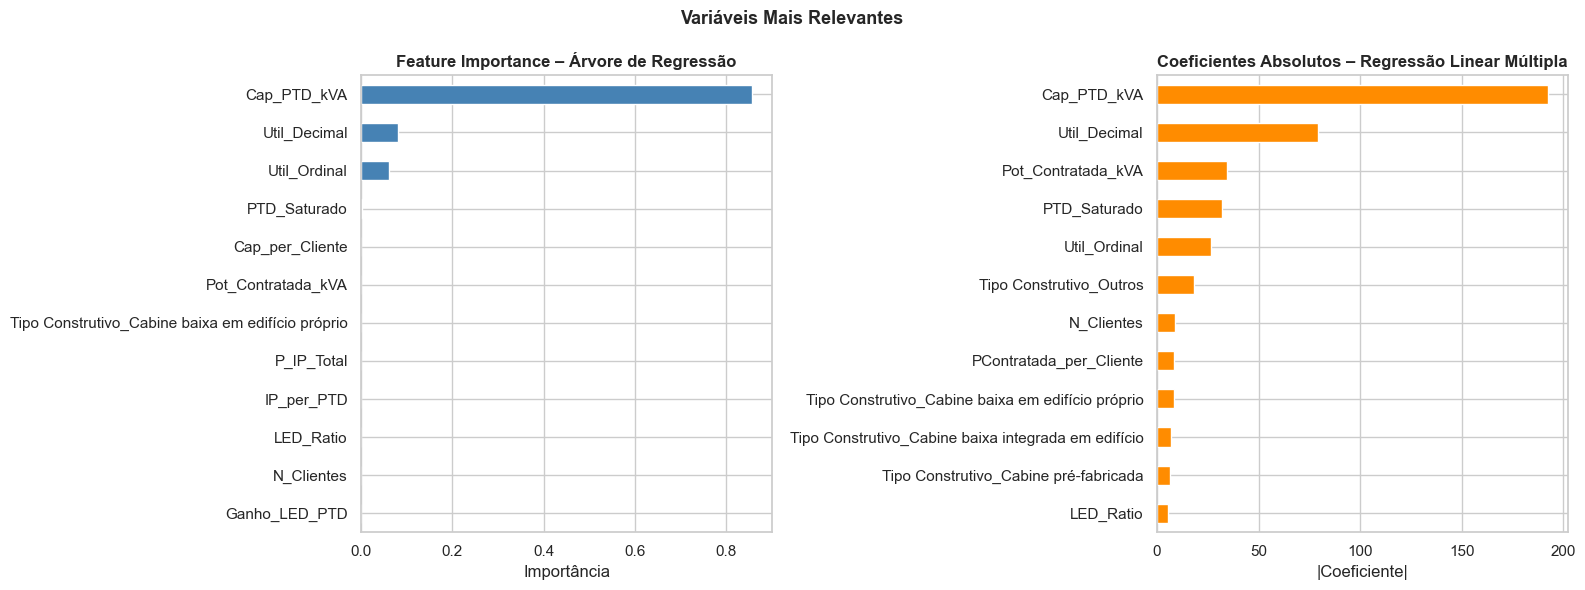

Top 5 variáveis (Árvore): ['Cap_PTD_kVA', 'Util_Decimal', 'Util_Ordinal', 'PTD_Saturado', 'Cap_per_Cliente']
Top 5 variáveis (MLR): ['Cap_PTD_kVA', 'Util_Decimal', 'Pot_Contratada_kVA', 'PTD_Saturado', 'Util_Ordinal']


In [19]:
# Importância das variáveis – Árvore de Regressão (melhor fold)
feat_imp_dt = pd.Series(best_dt.feature_importances_, index=feature_cols).sort_values(ascending=False)

# Importância dos coeficientes – Regressão Linear Múltipla (último fold)
# Re-treina no dataset completo para coeficientes finais
X_full = X.copy().astype(float)
scaler_full = StandardScaler()
X_full[:, idx_norm] = scaler_full.fit_transform(X_full[:, idx_norm])
mlr_full = LinearRegression().fit(X_full, y)
feat_imp_mlr = pd.Series(np.abs(mlr_full.coef_), index=feature_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

feat_imp_dt.head(12).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('Feature Importance – Árvore de Regressão', fontweight='bold')
axes[0].set_xlabel('Importância')

feat_imp_mlr.head(12).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].invert_yaxis()
axes[1].set_title('Coeficientes Absolutos – Regressão Linear Múltipla', fontweight='bold')
axes[1].set_xlabel('|Coeficiente|')

plt.suptitle('Variáveis Mais Relevantes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_feature_importance_reg.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 variáveis (Árvore):', feat_imp_dt.head(5).index.tolist())
print('Top 5 variáveis (MLR):', feat_imp_mlr.head(5).index.tolist())

---
## 5. Curvas de Aprendizagem – Dois Melhores Modelos

Os dois melhores modelos: ['Rede Neuronal', 'Árvore de Regressão']


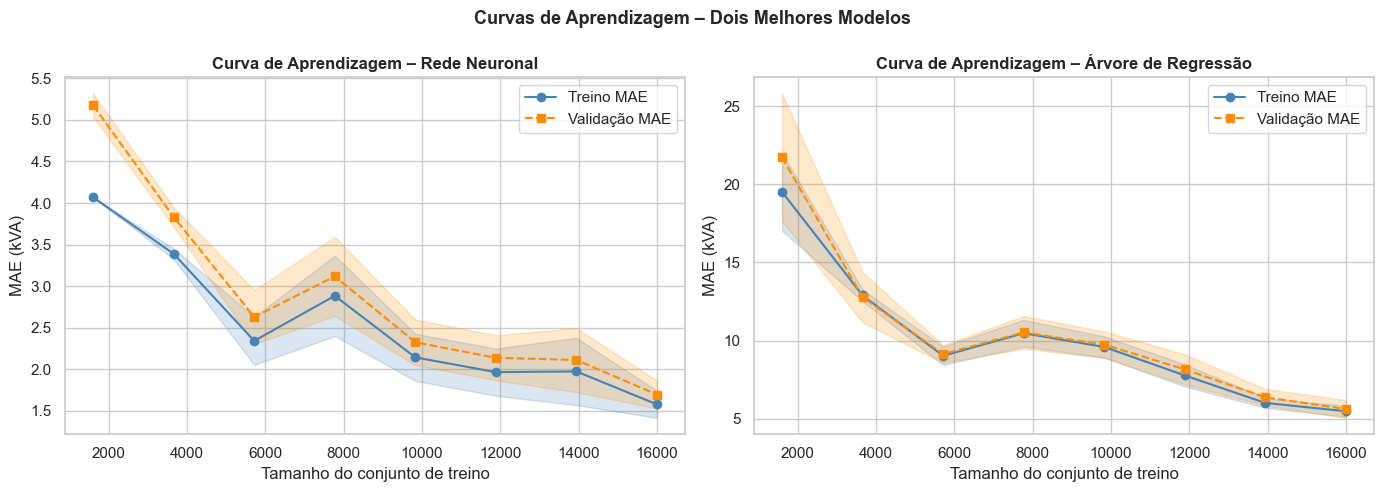

In [20]:
# Identificar os dois melhores modelos (menor MAE)
top2 = results.head(2)['Modelo'].tolist()
print(f'Os dois melhores modelos: {top2}')

# Mapeamento modelo → estimador sklearn (todos nativos, sem TensorFlow)
model_map = {
    'Reg. Linear Simples':  LinearRegression(),
    'Reg. Linear Múltipla': LinearRegression(),
    'Árvore de Regressão':  DecisionTreeRegressor(max_depth=6, min_samples_leaf=50, random_state=SEED),
    'SVM':                  SVR(kernel=best_kernel, C=10, epsilon=0.1),
    'Rede Neuronal':        MLPRegressor(
                                hidden_layer_sizes=best_nn_cfg['hidden_layer_sizes'],
                                activation='relu', solver='adam',
                                alpha=best_nn_cfg['alpha'],
                                learning_rate_init=best_nn_cfg['learning_rate_init'],
                                max_iter=200, early_stopping=True,
                                n_iter_no_change=10, random_state=SEED),
}

# Para as curvas de aprendizagem usa-se uma amostra (máx 20k) por eficiência
MAX_LC = 20000
idx_lc = np.random.choice(len(X_full), size=min(MAX_LC, len(X_full)), replace=False)
X_lc = X_full[idx_lc]
y_lc = y[idx_lc]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model_name in zip(axes, top2):
    if model_name not in model_map:
        ax.set_visible(False)
        continue

    estimator = model_map[model_name]

    # Regressão linear simples usa apenas Cap_PTD_kVA
    if model_name == 'Reg. Linear Simples':
        cap_idx = feature_cols.index('Cap_PTD_kVA')
        X_lc_use = X_lc[:, [cap_idx]]
    else:
        X_lc_use = X_lc

    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X_lc_use, y_lc,
        cv=5, scoring='neg_mean_absolute_error',
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )

    train_mean = -train_scores.mean(axis=1)
    train_std  =  train_scores.std(axis=1)
    val_mean   = -val_scores.mean(axis=1)
    val_std    =  val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='steelblue',  label='Treino MAE')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.2, color='steelblue')
    ax.plot(train_sizes, val_mean, 's--', color='darkorange', label='Validação MAE')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.2, color='darkorange')

    ax.set_xlabel('Tamanho do conjunto de treino')
    ax.set_ylabel('MAE (kVA)')
    ax.set_title(f'Curva de Aprendizagem – {model_name}', fontweight='bold')
    ax.legend()

plt.suptitle('Curvas de Aprendizagem – Dois Melhores Modelos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_learning_curves_reg.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretação das Curvas de Aprendizagem:**

- Se a curva de **validação converge para a de treino** à medida que os dados aumentam e ambas atingem um patamar baixo → treino eficiente, sem overfitting nem underfitting significativo.
- Se a curva de **validação se mantém muito acima da de treino** mesmo com muitos dados → **overfitting**: o modelo memoriza o treino mas não generaliza. Soluções: regularização, redução de complexidade, mais dados.
- Se **ambas as curvas estão em patamares elevados** e próximos entre si → **underfitting**: o modelo é demasiado simples para capturar a estrutura dos dados. Soluções: aumentar complexidade ou adicionar features.

A análise das curvas indica se os modelos beneficiariam de mais dados de treino ou se o problema é estrutural (modelo inadequado).

---
## 6. Significância Estatística dos Dois Melhores Modelos

In [21]:
# Recolher erros absolutos por fold para os 2 melhores modelos
# para aplicar testes estatísticos pareados

errors_per_model = {}

for model_name in top2:
    fold_maes = []
    if model_name == 'Reg. Linear Múltipla':
        fold_maes = mae_mlr
    elif model_name == 'Árvore de Regressão':
        fold_maes = mae_dt
    elif model_name == 'Reg. Linear Simples':
        fold_maes = mae_scores
    elif model_name == 'SVM':
        fold_maes = mae_svm
    elif model_name == 'Rede Neuronal':
        fold_maes = mae_nn
    errors_per_model[model_name] = np.array(fold_maes)

m1, m2 = top2[0], top2[1]
e1 = errors_per_model[m1]
e2 = errors_per_model[m2]

print(f'Modelo 1: {m1}')
print(f'  MAE por fold: {np.round(e1, 4)}')
print(f'  Média: {e1.mean():.4f} ± {e1.std():.4f} kVA')
print()
print(f'Modelo 2: {m2}')
print(f'  MAE por fold: {np.round(e2, 4)}')
print(f'  Média: {e2.mean():.4f} ± {e2.std():.4f} kVA')

Modelo 1: Rede Neuronal
  MAE por fold: [0.9199 0.9258 0.6628 1.068  0.9615 1.2201 1.592  1.0793 0.5852 0.7386]
  Média: 0.9753 ± 0.2777 kVA

Modelo 2: Árvore de Regressão
  MAE por fold: [4.7078 2.7885 2.965  4.2656 5.1733 2.9476 2.7085 3.5117 5.2092 2.6689]
  Média: 3.6946 ± 0.9901 kVA


In [22]:
alpha = 0.05

# Verificar normalidade das diferenças (Shapiro-Wilk)
diffs = e1 - e2
stat_sw, p_sw = stats.shapiro(diffs)
print(f'Teste de Shapiro-Wilk nas diferenças MAE:')
print(f'  W = {stat_sw:.4f}, p-value = {p_sw:.4f}')
normal = p_sw > alpha
print(f'  Diferenças {'normais' if normal else 'não-normais'} (α=0.05)')
print()

if normal:
    # t-test pareado
    stat_t, p_t = stats.ttest_rel(e1, e2)
    print(f'Teste t pareado:')
    print(f'  t = {stat_t:.4f}, p-value = {p_t:.4f}')
    p_val = p_t
    test_name = 't-test pareado'
else:
    # Wilcoxon signed-rank (não paramétrico)
    stat_w, p_w = stats.wilcoxon(e1, e2)
    print(f'Teste de Wilcoxon signed-rank:')
    print(f'  W = {stat_w:.4f}, p-value = {p_w:.4f}')
    p_val = p_w
    test_name = 'Wilcoxon signed-rank'

print()
print(f'Conclusão ({test_name}, α=0.05):')
if p_val < alpha:
    melhor = m1 if e1.mean() < e2.mean() else m2
    print(f'  p-value = {p_val:.4f} < 0.05 → diferença estatisticamente significativa.')
    print(f'  O modelo "{melhor}" apresenta desempenho significativamente melhor.')
else:
    print(f'  p-value = {p_val:.4f} ≥ 0.05 → diferença NÃO estatisticamente significativa.')
    print(f'  Não é possível concluir que um modelo supera o outro a α=0.05.')

Teste de Shapiro-Wilk nas diferenças MAE:
  W = 0.9346, p-value = 0.4945
  Diferenças normais (α=0.05)

Teste t pareado:
  t = -7.3286, p-value = 0.0000

Conclusão (t-test pareado, α=0.05):
  p-value = 0.0000 < 0.05 → diferença estatisticamente significativa.
  O modelo "Rede Neuronal" apresenta desempenho significativamente melhor.


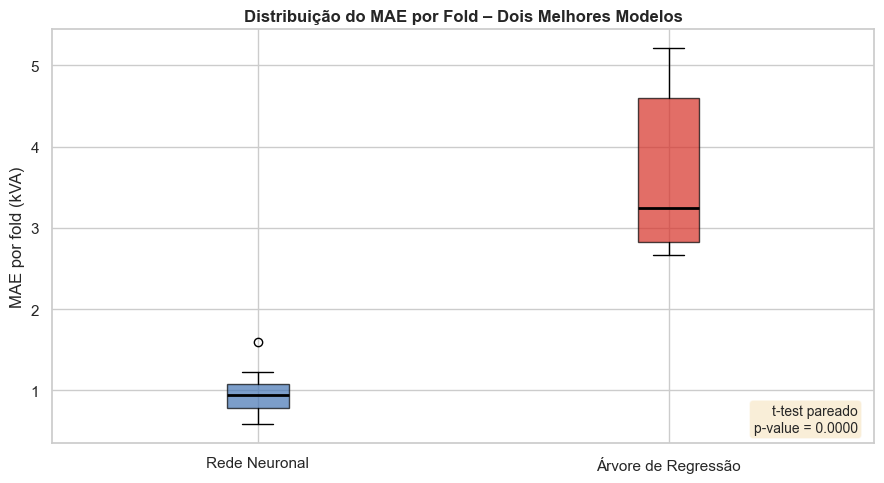

In [23]:
# Visualização: boxplot dos erros por fold
fig, ax = plt.subplots(figsize=(9, 5))

data_plot = [e1, e2]
bp = ax.boxplot(data_plot, labels=[m1, m2], patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
colors_bp = ['#4575b4', '#d73027']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('MAE por fold (kVA)')
ax.set_title('Distribuição do MAE por Fold – Dois Melhores Modelos', fontweight='bold')
ax.text(0.98, 0.02,
        f'{test_name}\np-value = {p_val:.4f}',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('fig_stat_test_reg.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sumário Final

In [24]:
print('=' * 65)
print('         SUMÁRIO – MODELOS DE REGRESSÃO (PFolga_PTD)')
print('=' * 65)
print(results[['Modelo','MAE','RMSE']].to_string(index=False, float_format='%.4f'))
print('=' * 65)
print(f'\nDois melhores modelos: {top2[0]}  e  {top2[1]}')
print(f'Teste estatístico aplicado: {test_name}')
print(f'p-value = {p_val:.4f}  (α = 0.05)')
if p_val < alpha:
    melhor = m1 if e1.mean() < e2.mean() else m2
    print(f'Modelo com melhor desempenho estatisticamente significativo: {melhor}')
else:
    print('Diferença entre os dois melhores modelos NÃO é estatisticamente significativa.')

print(f'\nVariável mais relevante (Árvore): {feat_imp_dt.index[0]}')
print(f'Variável mais relevante (MLR):    {feat_imp_mlr.index[0]}')

         SUMÁRIO – MODELOS DE REGRESSÃO (PFolga_PTD)
              Modelo     MAE    RMSE
       Rede Neuronal  0.9753  2.6932
 Árvore de Regressão  3.6946 24.8388
                 SVM 13.0103 75.4556
Reg. Linear Múltipla 27.2513 40.2473
 Reg. Linear Simples 50.7496 74.9728

Dois melhores modelos: Rede Neuronal  e  Árvore de Regressão
Teste estatístico aplicado: t-test pareado
p-value = 0.0000  (α = 0.05)
Modelo com melhor desempenho estatisticamente significativo: Rede Neuronal

Variável mais relevante (Árvore): Cap_PTD_kVA
Variável mais relevante (MLR):    Cap_PTD_kVA
